# L1.4 — Probability, Softmax, and Entropy

Hands-on notebook for the lesson [`1-4-probability.mdx`](../../llm-quest-theory/level-1/1-4-probability.mdx).

> **Learning objectives**
> - Simulate Bernoulli, Uniform, and Normal random variables and recover their theoretical mean / variance.
> - Implement softmax, inspect how temperature changes the distribution, and compute entropy.
> - Apply Bayes' theorem by simulation on a toy medical-test scenario.

## Connection to the theory
Covers **§1–§5** of the `.mdx`. An LLM's output at every step is a probability distribution — you cannot reason about sampling, temperature, or cross-entropy without these foundations.

In [1]:
# ---- Setup ----
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

## 1. Three distributions, side by side
Sample 20 000 values from Bernoulli(p=0.3), Uniform(-1, 1), and Normal(mu=0, sigma=1) and plot their histograms.

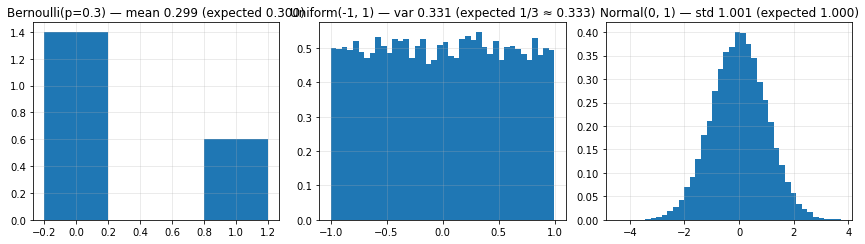

In [2]:
n = 20_000
bern = (np.random.rand(n) < 0.3).astype(int)
unif = np.random.uniform(-1, 1, n)
norm = np.random.normal(0, 1, n)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
axes[0].hist(bern, bins=[-0.25, 0.25, 0.75, 1.25], density=True, rwidth=0.8)
axes[0].set_title(f"Bernoulli(p=0.3) — mean {bern.mean():.3f} (expected 0.300)")
axes[1].hist(unif, bins=40, density=True)
axes[1].set_title(f"Uniform(-1, 1) — var {unif.var():.3f} (expected 1/3 ≈ 0.333)")
axes[2].hist(norm, bins=40, density=True)
axes[2].set_title(f"Normal(0, 1) — std {norm.std():.3f} (expected 1.000)")
for a in axes: a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 2. Expectation and variance from scratch
Verify the formulas `E[X] = sum x * p(x)` and `Var(X) = E[(X-E[X])^2]` on a discrete die.

In [3]:
# Fair 6-sided die
xs = np.arange(1, 7)
ps = np.full(6, 1/6)

mean = float(np.sum(xs * ps))
var  = float(np.sum((xs - mean) ** 2 * ps))
print(f"theoretical mean = {mean} (expected 3.5)")
print(f"theoretical var  = {var:.4f} (expected 35/12 ≈ 2.9167)")

# Monte Carlo estimate
samples = np.random.randint(1, 7, 100_000)
print(f"sampled    mean = {samples.mean():.4f}")
print(f"sampled    var  = {samples.var():.4f}")

theoretical mean = 3.5 (expected 3.5)
theoretical var  = 2.9167 (expected 35/12 ≈ 2.9167)
sampled    mean = 3.4997
sampled    var  = 2.9151


## 3. Softmax — from logits to probabilities

$$\mathrm{softmax}(z_i) = \frac{e^{z_i / T}}{\sum_j e^{z_j / T}}$$

The temperature `T` is a knob for "how confident" the distribution is:
- `T -> 0`: approaches argmax (one-hot).
- `T = 1`: the usual softmax.
- `T -> inf`: approaches uniform.

In [4]:
def softmax(z, temperature=1.0):
    z = np.asarray(z, dtype=float) / temperature
    z = z - z.max()  # numerical stability
    e = np.exp(z)
    return e / e.sum()

vocab = ["couch", "bed", "rug", "floor", "chair"]
logits = np.array([2.0, 1.6, 1.1, 0.5, -0.3])

for T in [0.3, 1.0, 3.0]:
    p = softmax(logits, T)
    print(f"T = {T}  probs = {np.round(p, 3)}  sum = {p.sum():.3f}")

T = 0.3  probs = [0.757 0.2   0.038 0.005 0.   ]  sum = 1.000
T = 1.0  probs = [0.417 0.279 0.169 0.093 0.042]  sum = 1.000
T = 3.0  probs = [0.271 0.237 0.201 0.165 0.126]  sum = 1.000


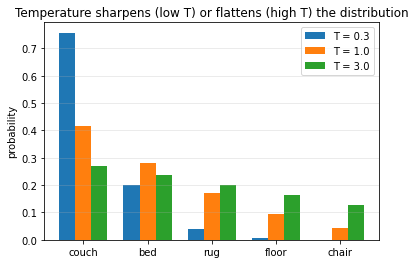

In [5]:
width = 0.25
xs = np.arange(len(vocab))

fig, ax = plt.subplots()
for i, T in enumerate([0.3, 1.0, 3.0]):
    p = softmax(logits, T)
    ax.bar(xs + (i - 1) * width, p, width=width, label=f"T = {T}")
ax.set_xticks(xs); ax.set_xticklabels(vocab)
ax.set_ylabel("probability"); ax.grid(alpha=0.3, axis="y"); ax.legend()
ax.set_title("Temperature sharpens (low T) or flattens (high T) the distribution")
plt.show()

## 4. Entropy — a measure of uncertainty

$$H(P) = -\sum_i P(x_i)\log P(x_i)$$

In [6]:
def entropy(p, eps=1e-12):
    p = np.asarray(p)
    return float(-np.sum(p * np.log(p + eps)))

cases = {
    "one-hot":   np.array([1.0, 0, 0, 0, 0]),
    "confident": softmax(logits, 0.3),
    "baseline":  softmax(logits, 1.0),
    "flat":      softmax(logits, 3.0),
    "uniform":   np.full(5, 0.2),
}
for name, p in cases.items():
    print(f"{name:<10} H = {entropy(p):.4f}  max possible = {np.log(len(p)):.4f}")

one-hot    H = -0.0000  max possible = 1.6094
confident  H = 0.6856  max possible = 1.6094
baseline   H = 1.3752  max possible = 1.6094
flat       H = 1.5756  max possible = 1.6094
uniform    H = 1.6094  max possible = 1.6094


As the distribution gets flatter, entropy approaches `log(V)` (maximum uncertainty). A perfectly one-hot distribution has `H = 0`.

## 5. Bayes' theorem by simulation

Disease prevalence `P(D) = 1%`. Test sensitivity `P(T+ | D) = 95%`. False-positive rate `P(T+ | ¬D) = 5%`. Question: **given a positive test, what is the probability you actually have the disease?** Many people guess 95% — the real answer is much smaller.

$$P(D \mid T^+) = \frac{P(T^+ \mid D) \, P(D)}{P(T^+ \mid D) P(D) + P(T^+ \mid \lnot D) P(\lnot D)}$$

In [7]:
# Closed-form
P_D   = 0.01
P_Tp_D  = 0.95
P_Tp_nD = 0.05
posterior = (P_Tp_D * P_D) / (P_Tp_D * P_D + P_Tp_nD * (1 - P_D))
print(f"P(D | T+) closed-form = {posterior:.4f}")

# Simulation
N = 200_000
has_disease = np.random.rand(N) < P_D
tests_positive = np.where(
    has_disease, np.random.rand(N) < P_Tp_D, np.random.rand(N) < P_Tp_nD
)
# Of those who tested positive, what fraction actually have the disease?
pos_mask = tests_positive
est = has_disease[pos_mask].mean()
print(f"P(D | T+) simulated    = {est:.4f}")

P(D | T+) closed-form = 0.1610
P(D | T+) simulated    = 0.1614


Only ~16% despite the test being "95% accurate" — a vivid reminder that prior probabilities dominate when events are rare.

## 6. Sampling from a categorical distribution
LLMs sample a token at every step. Here we simulate pulling 2 000 draws from our 5-token distribution at different temperatures.

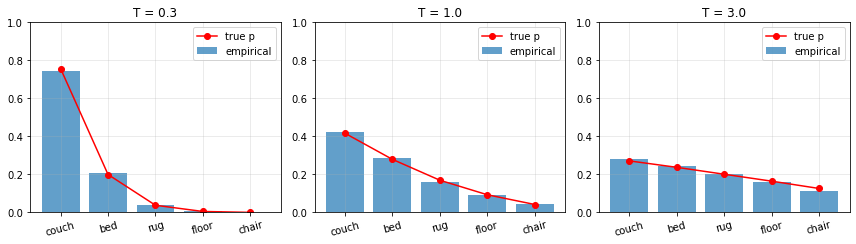

In [8]:
def sample_from(probs, n, rng):
    return rng.choice(len(probs), size=n, p=probs)

rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, T in zip(axes, [0.3, 1.0, 3.0]):
    p = softmax(logits, T)
    draws = sample_from(p, 2000, rng)
    freq = np.bincount(draws, minlength=len(vocab)) / 2000
    ax.bar(range(len(vocab)), freq, alpha=0.7, label="empirical")
    ax.plot(range(len(vocab)), p, "ro-", label="true p")
    ax.set_xticks(range(len(vocab))); ax.set_xticklabels(vocab, rotation=15)
    ax.set_title(f"T = {T}"); ax.set_ylim(0, 1); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

## 7. Quick checks

In [9]:
p = softmax([3.0, 1.0, -1.0])
assert np.isclose(p.sum(), 1.0)
assert np.argmax(p) == 0, "softmax must preserve argmax ordering"
assert entropy([1.0, 0, 0, 0]) < 1e-6, "one-hot has zero entropy"
assert abs(entropy([0.25] * 4) - np.log(4)) < 1e-6, "uniform over 4 = log 4"
assert 0.14 < posterior < 0.20
print("OK — probability toolbox verified.")

OK — probability toolbox verified.


## Reflection questions

1. Why does softmax need the `z - z.max()` trick? What happens numerically without it on large logits?
2. If a model always assigns 99.9% probability to the correct token, does that mean it is "well-calibrated"? When might overconfidence hurt?
3. Connect entropy to cross-entropy from lesson 1-1: what does it mean when the LLM's per-token cross-entropy equals `log V` (the vocabulary size)?
4. In the Bayes example, what happens to `P(D | T+)` if disease prevalence rises from 1% to 50%? Try it.

## References
- Source theory: [`1-4-probability.mdx`](../../llm-quest-theory/level-1/1-4-probability.mdx)
- Next: [`1-5-tune-boss`](1-5-tune-boss.ipynb) — the Level 1 boss.